In [1]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import copy
import string
import random

In [2]:
from kafka import KafkaConsumer, TopicPartition
import json
import numpy as np
import time
import matplotlib.mlab as mlab
from baskervillehall.baskervillehall_isolation_forest import ModelType
import pandas as pd
from sklearn.preprocessing import StandardScaler
from baskervillehall.baskervillehall_isolation_forest import BaskervillehallIsolationForest
from baskervillehall.baskervillehall_isolation_forest import ModelType

2025-06-25 09:18:47.200525: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750843127.229679      79 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750843127.238564      79 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750843127.264695      79 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750843127.264735      79 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750843127.264738      79 computation_placer.cc:177] computation placer alr

In [3]:
import logging
import sys
logger = logging.getLogger('ai')
logger.addHandler(logging.StreamHandler())
logger.addHandler(logging.StreamHandler(sys.stdout))
logger.setLevel('DEBUG')

In [4]:
kafka_url = ['kafka9-0.kafka9-headless.default.svc.cluster.local:9093','kafka9-1.kafka9-headless.default.svc.cluster.local:9093','kafka9-2.kafka9-headless.default.svc.cluster.local:9093']
partitions = {
    'vytoki.net': 0,
    'zhitomir.info': 1,
    'urban-pushkino.ru': 0,
    'dev.emawpb.org': 0,
    'palestinechronicle.com': 1,
    'equalit.ie': 0,
    'lexota.org': 0,
    'kavkaz-uzel.eu': 0,
    'amp.kavkaz-uzel.eu': 2,
    'indymedia.nl': 0,
    'btselem.org': 0,
    'verafiles.org': 1,
    'telegraf.in.ua': 2,
    'gubernia.com': 1,
    'informator.ua': 0,
    'culturesofresistance.org': 2,
    'zmina.info': 1,
    'memex.craphound.com': 2,
    'greencubator.info': 0
}
datetime_format = '%Y-%m-%d %H:%M:%S'
topic = 'BASKERVILLEHALL_4'

In [5]:
features = [
    'request_rate',
    'post_rate',
    'request_interval_average',
    'request_interval_std',
    'response4xx_to_request_ratio',
    'top_page_to_request_ratio',
    'unique_path_rate',
    'unique_path_to_request_ratio',
    'unique_query_rate',
    'unique_query_to_unique_path_ratio',
    'image_to_html_ratio',
    'js_to_html_ratio',
    'css_to_html_ratio',
    'path_depth_average',
    'path_depth_std',
    'payload_size_log_average',
    'entropy',
    'edge_count',
    'static_ratio',
    'ua_count',
    'api_ratio',
    'num_ciphers',
    'num_languages',
    'hour_bucket',
    'odd_hour'
]
categorical_features=[
            'country',
            'primary_session',
            'cipher',
            'valid_browser_ciphers',
            'weak_cipher',
            'headless_ua',
            'bot_ua',
            'ai_bot_ua',
            'verified_bot',
            'datacenter_asn',
            'short_ua',
]

In [6]:
def read_sessions(host, size=1000, model_type=None):
    consumer = KafkaConsumer(bootstrap_servers=kafka_url)
    
    num = 0
    partition = partitions[host]
    
    print(f'Reading from kafka. Host = {host} ... partition = {partition}')
    time_now = int(time.time())
    sessions = []

    consumer.assign([TopicPartition(topic, partition)])
    consumer.seek_to_beginning()
    complete = False
    while not complete:
        raw_messages = consumer.poll(timeout_ms=1000, max_records=100)

        for topic_partition, messages in raw_messages.items():
            for message in messages:
                # prevent from getting messages too close to the current time
                time_diff_in_minutes = (time_now - message.timestamp / 1000) / 60
                if time_diff_in_minutes < 2:
                    print(f'{time_diff_in_minutes} minutes. Topic offset is too close to the current times...')
                    complete = True
                    break
                
                if message.value is None :
                    continue
                if message.key is None:
                    continue
                if message.key.decode("utf-8") != host:
                    continue

                session = json.loads(message.value.decode("utf-8"))       
                    
                if model_type == ModelType.HUMAN:
                    if not session['human']:
                        continue
                elif model_type == ModelType.BOT:
                    if session['human']:
                        continue
                        
                if len(sessions) == 0:
                    print(f'First session start = {session["start"]} end = {session["end"]}')

                sessions.append(session)
                if num == size:
                    complete = True
                    break
                num += 1
                if num % 100 == 0:
                    print(f'{num} sessions read', session['end'], message.timestamp)           
    return sessions

In [7]:
host = 'zhitomir.info'
sessions = read_sessions(host=host, size=5000, model_type=ModelType.HUMAN)

Reading from kafka. Host = zhitomir.info ... partition = 1
First session start = 2025-06-24 09:04:25 end = 2025-06-24 09:05:03
100 sessions read 2025-06-24 09:16:30 1750756613279
200 sessions read 2025-06-24 09:25:36 1750757150352
300 sessions read 2025-06-24 09:36:21 1750757791790
400 sessions read 2025-06-24 09:43:43 1750758239274
500 sessions read 2025-06-24 09:50:41 1750758645606
600 sessions read 2025-06-24 09:58:27 1750759114284
700 sessions read 2025-06-24 10:09:03 1750759752283
800 sessions read 2025-06-24 10:15:54 1750760164620
900 sessions read 2025-06-24 10:26:14 1750760786317
1000 sessions read 2025-06-24 10:34:43 1750761290392
1100 sessions read 2025-06-24 10:43:00 1750761785295
1200 sessions read 2025-06-24 10:54:33 1750762483243
1300 sessions read 2025-06-24 11:03:37 1750763027240
1400 sessions read 2025-06-24 11:12:58 1750763590412
1500 sessions read 2025-06-24 11:23:13 1750764201415
1600 sessions read 2025-06-24 11:33:18 1750764811932
1700 sessions read 2025-06-24 11:4

In [37]:
import re
from urllib.parse import urlparse, unquote
from collections import Counter

def extract_words_from_url(url):
    url = unquote(url)
    parsed_url = urlparse(url)
    parts = parsed_url.netloc.split('.')[:-2] + parsed_url.path.split('/') + parsed_url.query.split('&')
    combined = ' '.join(parts).replace('-', ' ').replace('_', ' ')
    word_pattern = re.compile(r'\b[a-zA-Z0-9]+\b')
    words = word_pattern.findall(combined)
    return [w.lower() for w in words if len(w) > 2]

# 1. Собираем все слова из всех сессий
word_counter = Counter()
for session in sessions:
    for req in session.get("requests", []):
        words = extract_words_from_url(req.get("url", ""))
        word_counter.update(words)

# 2. Топ-N слов 
TOP_N = 100
top_words = set([w for w, _ in word_counter.most_common(TOP_N)])

# 3. Преобразуем каждую сессию в строку из слов из top_words
def session_to_embedding_text(session):
    word_counts = Counter()
    
    for req in session.get("requests", []):
        words = extract_words_from_url(req.get("url", ""))
        for word in words:
            if word in top_words:
                word_counts[word] += 1

    weighted_words = []
    # if word_counts:
    #     # Нормализуем частоты, опционально можно взять log(1 + freq)
    #     max_freq = max(word_counts.values())     
    #     for word, freq in word_counts.items():
    #         norm_freq = int(5 * freq / max_freq)  # масштабируем до [1,5] повторений
    #         weighted_words.extend([word] * max(1, norm_freq))
    
    words = " ".join(weighted_words)
    
    # session-level metadata
    meta = []
    for key in ['country', 'timezone', 'asn_name', 'ua', 'accept_language',
               'cipher', 
                # 'ciphers'
               ]:
        val = session.get(key)
        if val not in [None, '', False]:
            meta.append(f"{key}:{val}")

    return " | ".join(meta) + " || " + words



In [38]:
sessions_text = [session_to_embedding_text(s) for s in sessions]
sessions_text[1]

'country:UA | timezone:Europe/Kiev | asn_name:PP Serih Olena Petrovna | ua:Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36 | accept_language:ru-RU,ru;q=0.9,en-US;q=0.8,en;q=0.7,uk;q=0.6 | cipher:TLS_AES_128_GCM_SHA256 || '

In [39]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
model_embeddings = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
model_embeddings.eval()

@torch.no_grad()
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    outputs = model_embeddings(**inputs)
    # Используем mean pooling
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

In [40]:
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModel
import torch

# Подготовка токенизатора и модели
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model_embeddings = AutoModel.from_pretrained("distilbert-base-uncased")
model_embeddings.eval()

# Параметры
batch_size = 256

# Батчинг входных текстов
dataloader = DataLoader(sessions_text[:batch_size], batch_size=batch_size)

all_embeddings = []
start_time = time.perf_counter()
with torch.no_grad():
    index = 0
    for batch in dataloader:
        print(f'batch {index}...')
        tokens = tokenizer(batch, padding=True, truncation=True, return_tensors="pt")
        outputs = model_embeddings(**tokens)
        embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        all_embeddings.append(embeddings)
        index += 1
        
end_time = time.perf_counter()

# Объединяем все батчи
embeddings = torch.cat(all_embeddings, dim=0)
print('Done')
print(f"Total embedding time: {(end_time - start_time):.2f} seconds")
print(f"Average per session: {(end_time - start_time) / len(dataloader.dataset) * 1000:.2f} ms")

batch 0...
Done
Total embedding time: 18.66 seconds
Average per session: 72.89 ms


In [15]:
from baskervillehall.feature_extractor import FeatureExtractor
fe = FeatureExtractor(features=features, categorical_features=categorical_features)
f_vectors = np.array(fe.fit_transform(sessions))
df_features = pd.DataFrame(f_vectors)
df_features[0]

0        18.947368
1        10.000000
2        80.000000
3         1.865285
4        97.500000
           ...    
4996    762.857143
4997     18.113208
4998    210.000000
4999    104.285714
5000     34.545455
Name: 0, Length: 5001, dtype: float64

In [211]:
X_combined = np.hstack([embeddings, df_features])
# X_combined = np.hstack([embeddings])
# X_combined = np.hstack([df_features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

In [212]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

In [213]:
import torch.nn as nn

class AutoEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [214]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

# Гиперпараметры
batch_size = 64
val_split = 0.2
num_epochs = 50
learning_rate = 1e-3

# Делим данные
dataset = TensorDataset(X_tensor)
val_size = int(len(dataset) * val_split)
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

# Модель
model = AutoEncoder(input_dim=X_tensor.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

# Тренировка с валидацией
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch[0])
        loss = loss_fn(out, batch[0])
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * batch[0].size(0)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            out = model(batch[0])
            loss = loss_fn(out, batch[0])
            total_val_loss += loss.item() * batch[0].size(0)

    avg_train_loss = total_train_loss / train_size
    avg_val_loss = total_val_loss / val_size

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.6f} | Val Loss = {avg_val_loss:.6f}")

Epoch 1: Train Loss = 0.412039 | Val Loss = 0.208277
Epoch 2: Train Loss = 0.173528 | Val Loss = 0.135496
Epoch 3: Train Loss = 0.124022 | Val Loss = 0.108760
Epoch 4: Train Loss = 0.102470 | Val Loss = 0.093124
Epoch 5: Train Loss = 0.089591 | Val Loss = 0.082921
Epoch 6: Train Loss = 0.079938 | Val Loss = 0.076385
Epoch 7: Train Loss = 0.073293 | Val Loss = 0.071601
Epoch 8: Train Loss = 0.067737 | Val Loss = 0.065740
Epoch 9: Train Loss = 0.063716 | Val Loss = 0.063330
Epoch 10: Train Loss = 0.060327 | Val Loss = 0.060257
Epoch 11: Train Loss = 0.057400 | Val Loss = 0.058093
Epoch 12: Train Loss = 0.054896 | Val Loss = 0.056705
Epoch 13: Train Loss = 0.053601 | Val Loss = 0.054926
Epoch 14: Train Loss = 0.051087 | Val Loss = 0.053083
Epoch 15: Train Loss = 0.049264 | Val Loss = 0.052240
Epoch 16: Train Loss = 0.048237 | Val Loss = 0.051254
Epoch 17: Train Loss = 0.046824 | Val Loss = 0.050542
Epoch 18: Train Loss = 0.045304 | Val Loss = 0.048555
Epoch 19: Train Loss = 0.044082 | Val

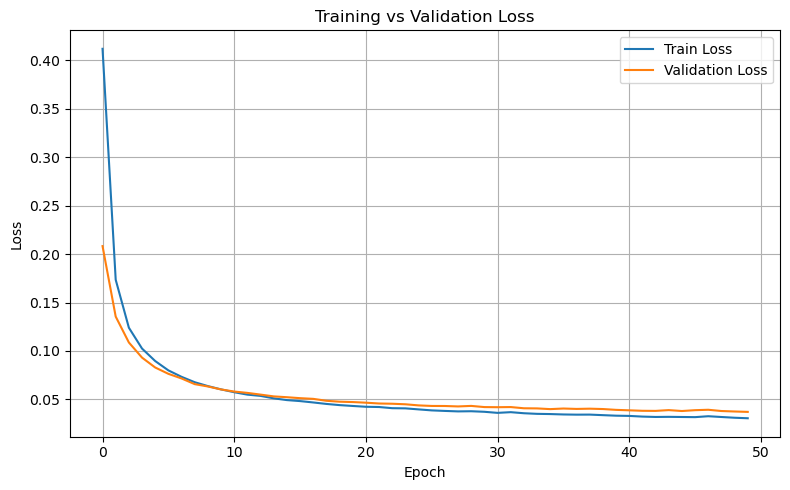

In [215]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [216]:
percentile = 0.95

In [217]:
import torch.nn.functional as F

# Пропускаем все данные через модель
model.eval()
inference_times = []
with torch.no_grad():
    start_time = time.perf_counter()
    recon = model(X_tensor)
    end_time = time.perf_counter()
    
    reconstruction_errors = F.mse_loss(recon, X_tensor, reduction='none')
    per_sample_error = reconstruction_errors.mean(dim=1)  # [num_samples]
    inference_times.append(end_time - start_time)

# Устанавливаем порог (например, 97-й перцентиль)
threshold = torch.quantile(per_sample_error, percentile)

# Определяем аномалии
is_anomaly = per_sample_error > threshold

# Считаем статистику
num_anomalies = is_anomaly.sum().item()
print(f"Detected {num_anomalies} anomalies out of {len(X_tensor)} sessions")

print(f"Average time per session: {np.mean(inference_times) * 1000:.3f} ms")
print(f"Max time: {np.max(inference_times) * 1000:.3f} ms")
print(f"Min time: {np.min(inference_times) * 1000:.3f} ms")


Detected 250 anomalies out of 5001 sessions
Average time per session: 57.063 ms
Max time: 57.063 ms
Min time: 57.063 ms


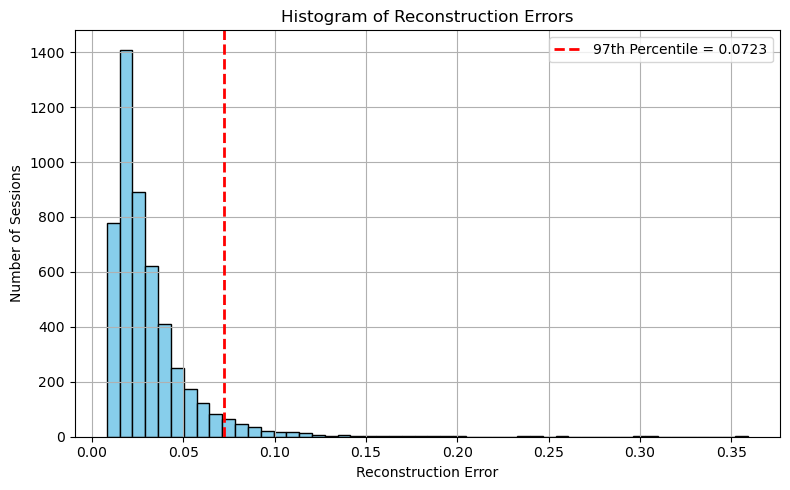

In [218]:
# Построим гистограмму
plt.figure(figsize=(8, 5))
plt.hist(per_sample_error, bins=50, color='skyblue', edgecolor='black')

# Добавим порог (97-й перцентиль)
threshold = np.percentile(per_sample_error, percentile*100)
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'97th Percentile = {threshold:.4f}')

plt.title("Histogram of Reconstruction Errors")
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Sessions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [219]:
# 2. Переводим в numpy для удобства
errors_np = per_sample_error.cpu().numpy()

# 4. Индексы аномалий
anomaly_indices = np.where(errors_np > threshold)[0]
print(f"Found {len(anomaly_indices)} anomalies out of {len(errors_np)} sessions")
print("Top 10 anomaly indices:", anomaly_indices[:10])

Found 250 anomalies out of 5001 sessions
Top 10 anomaly indices: [22 23 24 29 32 53 54 55 80 81]


In [220]:
threshold

0.07227221876382828

## Isolation Forest

In [202]:
model_if = BaskervillehallIsolationForest(
    features=features,
    categorical_features=categorical_features,
    n_estimators=1000,
    max_samples=256,
    contamination=1.0-percentile,
    max_features=0.7,
    bootstrap=True,
    n_jobs=4,
    random_state=777,
    logger=logger
)
model_if.fit(sessions)

In [203]:
train_scores, train_shapley = model_if.transform(sessions)

In [204]:
def challenge_rate(scores):
    return len(scores[scores < 0]) / len(scores)

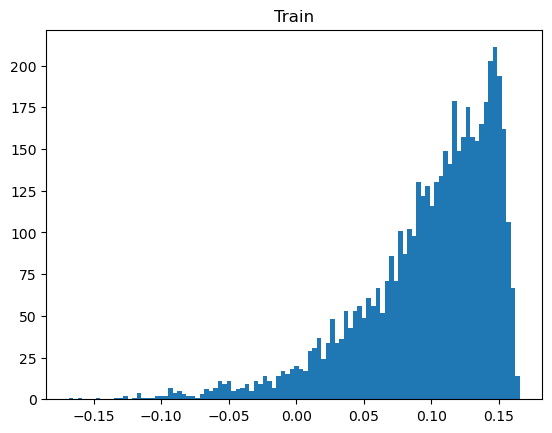

Challenge rate = 0.04999000199960008


In [205]:
a = np.hstack(train_scores)
_ = plt.hist(a, bins=100)  
plt.title('Train')
plt.show()
print(f'Challenge rate = {challenge_rate(train_scores)}')

In [221]:
if_anomaly_indices = np.where(train_scores < 0)[0]
print(if_anomaly_indices)

[   3    4   20   22   27   34   53   54   59   60   68   69   79  105
  112  113  118  123  129  131  132  144  151  175  177  232  234  235
  236  270  285  292  297  347  369  422  431  434  453  476  532  585
  608  613  615  626  632  673  717  773  820  894  896  937  941  969
  972  986 1002 1053 1065 1082 1101 1124 1125 1168 1177 1180 1190 1199
 1201 1214 1216 1256 1277 1280 1286 1310 1326 1362 1365 1421 1444 1456
 1483 1515 1524 1539 1541 1569 1576 1620 1667 1684 1736 1767 1782 1789
 1799 1825 1885 1888 1895 1912 1927 1962 1978 1985 2023 2026 2055 2074
 2083 2093 2106 2146 2214 2221 2225 2244 2258 2305 2322 2335 2337 2352
 2355 2399 2454 2499 2510 2539 2590 2604 2617 2636 2644 2658 2675 2701
 2716 2767 2771 2793 2806 2812 2901 2950 2989 3021 3037 3058 3062 3073
 3083 3091 3094 3110 3130 3133 3195 3210 3237 3251 3280 3291 3292 3303
 3331 3395 3443 3491 3536 3556 3558 3559 3563 3583 3598 3600 3604 3623
 3627 3645 3654 3655 3657 3668 3675 3685 3715 3720 3850 3865 3876 3907
 3944 

In [222]:
anomaly_indices

array([  22,   23,   24,   29,   32,   53,   54,   55,   80,   81,   83,
         85,  177,  191,  202,  218,  233,  281,  282,  284,  294,  299,
        317,  318,  325,  328,  342,  347,  358,  396,  397,  522,  523,
        524,  525,  538,  554,  566,  588,  601,  632,  648,  652,  654,
        747,  765,  803,  804,  811,  820,  829,  836,  858,  860,  863,
        876,  894,  948,  950, 1008, 1040, 1041, 1060, 1075, 1126, 1174,
       1192, 1220, 1260, 1261, 1266, 1272, 1280, 1294, 1356, 1401, 1423,
       1483, 1504, 1508, 1522, 1567, 1569, 1576, 1589, 1600, 1610, 1623,
       1673, 1675, 1692, 1693, 1699, 1729, 1730, 1732, 1766, 1783, 1792,
       1808, 1814, 1828, 1829, 1858, 1899, 1975, 1994, 2023, 2069, 2075,
       2096, 2123, 2141, 2148, 2161, 2221, 2225, 2266, 2267, 2268, 2270,
       2271, 2272, 2286, 2313, 2339, 2340, 2388, 2448, 2458, 2463, 2468,
       2529, 2604, 2641, 2644, 2691, 2692, 2701, 2703, 2816, 2818, 2823,
       2900, 2962, 2967, 2969, 2979, 3001, 3011, 30

In [226]:
common = set(anomaly_indices) & set(if_anomaly_indices)
num_common = len(common)

In [224]:
print(f'Anomalies AE = {len(anomaly_indices)}')
print(f'Anomalies IF = {len(if_anomaly_indices)}')
print(f'Common = {num_common}')

Anomalies AE = 250
Anomalies IF = 250
Common = 29


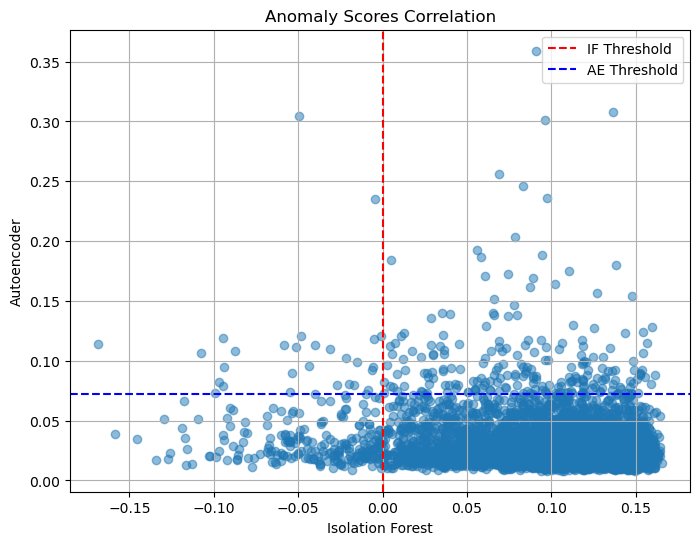

In [225]:
threshold_autoencoder = threshold  # например, 95-й перцентиль ошибок Autoencoder
threshold_isolation_forest = 0.0   # или другой порог, если есть

plt.figure(figsize=(8, 6))
plt.scatter(train_scores, errors_np, alpha=0.5)
plt.axvline(threshold_isolation_forest, color='red', linestyle='--', label='IF Threshold')
plt.axhline(threshold_autoencoder, color='blue', linestyle='--', label='AE Threshold')
plt.xlabel("Isolation Forest")
plt.ylabel("Autoencoder")
plt.title("Anomaly Scores Correlation")
plt.legend()
plt.grid(True)
plt.show()



In [232]:
sessions[common.pop()]

TypeError: set.pop() takes no arguments (1 given)

In [76]:
def compute_anomaly_scores(sessions, fe, model, 
                           tokenizer, model_embeddings, 
                           scaler=scaler,
                           device='cpu'):
    import torch
    import numpy as np
    from torch.nn import functional as F

    model.eval()
    model.to(device)
    model_embeddings.eval()
    model_embeddings.to(device)

    # 1. Преобразуем сессии в текст
    print('Sessions to text...')
    texts = [session_to_embedding_text(s) for s in sessions]

    # 2. Получаем эмбеддинги через transformer_model
    print('Embeddings...')
    all_embeddings = []
    batch_size = 32
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        tokens = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model_embeddings(**tokens)
            embeddings = outputs.last_hidden_state[:, 0, :]  # CLS токен
            all_embeddings.append(embeddings.cpu())
            
    embeddings = torch.cat(all_embeddings, dim=0)
    print(embeddings[0][0:3])

    # 3. (Если используем только эмбеддинги — оставить как есть)
    combined = np.hstack([embeddings])
    X_scaled = scaler.transform(combined)  
    print(X_scaled[0][0:3])

    # 4. Прогон через автоэнкодер и вычисление ошибок
    with torch.no_grad():
        X_scaled_tensor = torch.tensor(X_scaled, dtype=torch.float32)
        recon = model(X_scaled_tensor)
        
        reconstruction_errors = F.mse_loss(recon, X_scaled_tensor, reduction='none')
        anomaly_scores = reconstruction_errors.mean(dim=1).cpu().numpy()

    return anomaly_scores



In [79]:
score = compute_anomaly_scores([sessions[anomaly_indices[0]]], fe=fe, model=model, 
                       tokenizer=tokenizer, 
                       scaler=scaler,
                       model_embeddings=model_embeddings)
print(f'score = {score}, threshold={threshold}')

Sessions to text...
Embeddings...
tensor([-0.3411, -0.1483, -0.2147])
[ 2.0123544 -0.4929667 -1.2003897]
score = [0.20082831], threshold=0.13323630392551422


In [126]:
def modify_session(session):
    res = copy.deepcopy(session)
    for r in res['requests']:
        r['url'] = '/' 
        # r['url'] = res['requests'][0]['url']
    return res

In [129]:
i = 100
score1 = compute_anomaly_scores([sessions[i]], fe=fe, model=model, 
                       tokenizer=tokenizer, 
                       scaler=scaler,
                       model_embeddings=model_embeddings)
score2 = compute_anomaly_scores([modify_session(sessions[i])], fe=fe, model=model, 
                       tokenizer=tokenizer, 
                       scaler=scaler,
                       model_embeddings=model_embeddings)

print(f'original = {score1}, modified={score2}, threshold={threshold}')

Sessions to text...
Embeddings...
tensor([-0.4442, -0.1443, -0.1167])
[-0.5049909  -0.40781993  1.6781645 ]
Sessions to text...
Embeddings...
tensor([-0.4770, -0.0944, -0.2588])
[-1.3052441   0.66445875 -2.496871  ]
original = [0.0403545], modified=[0.17918833], threshold=0.13323630392551422


In [117]:

print(f'score = {score}, threshold={threshold}')

Sessions to text...
Embeddings...
tensor([-0.4586, -0.1554, -0.1697])
[-0.8543404  -0.6443892   0.12101789]
score = [0.41761768], threshold=0.13323630392551422


In [56]:
print(embeddings[anomaly_indices[0]][0:3])

tensor([-0.3411, -0.1483, -0.2147])


In [66]:
print(X_tensor[anomaly_indices[0]][0:3])

tensor([ 2.0124, -0.4930, -1.2004])


In [72]:
scaler.transform(X_combined)[anomaly_indices[0]][0:3]

array([ 2.012353  , -0.49296734, -1.2003907 ], dtype=float32)

In [34]:
# Предположим:
embedding_dim = embeddings.shape[1]

# Получаем только часть с фичами
X_features_only = X_combined[:, embedding_dim:]


In [35]:
import shap
import numpy as np
import torch

# Преобразуем X_features_only в тензор
X_tensor = torch.tensor(X_features_only, dtype=torch.float32, requires_grad=True)

# Получаем feature_names
feature_names = np.array(fe.get_all_features())

# Background (например, 100 случайных)
background = X_tensor[torch.randperm(len(X_tensor))[:100]]

# SHAP GradientExplainer
explainer = shap.GradientExplainer(model, background)



RuntimeError: mat1 and mat2 shapes cannot be multiplied (100x35 and 803x256)

In [ ]:
# Одна аномальная сессия (например, первая)
target = X_tensor[anomaly_indices[0]].unsqueeze(0)
shap_values = explainer.shap_values(target)

# Визуализация
shap.summary_plot(
    shap_values,
    features=target.detach().numpy(),
    feature_names=feature_names
)
